<a href="https://colab.research.google.com/github/EvelynRobert/US-Accident-Modeling-DS4420/blob/main/TimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Time Series Data Prep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/accidents_sample.csv')

# select features and parse timestamps
cols = ['Start_Time', 'Severity', 'Temperature(F)', 'Humidity(%)',
        'Visibility(mi)', 'Weather_Condition', 'Sunrise_Sunset',
        'State', 'Distance(mi)']
df = df[cols].dropna(subset=['Start_Time'])

df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df = df.dropna(subset=['Start_Time'])

# extract temporal features
df['Date']      = df['Start_Time'].dt.date.astype(str)
df['Year']      = df['Start_Time'].dt.year.astype('int32')
df['Month']     = df['Start_Time'].dt.month.astype('int32')
df['Hour']      = df['Start_Time'].dt.hour.astype('int32')
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek.astype('int32')

# impute missing numeric values with column medians
for col in ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Distance(mi)']:
    df[col] = df[col].fillna(df[col].median())

df.head()

,Start_Time,Severity,Temperature(F),Humidity(%),Visibility(mi),Weather_Condition,Sunrise_Sunset,State,Distance(mi),Date,Year,Month,Hour,DayOfWeek
0,2020-04-25 17:48:08,2,88.0,63.0,10.0,Mostly Cloudy,Day,FL,0.000,2020-04-25,2020,4,17,5
1,2021-03-29 23:34:00,2,44.0,40.0,10.0,Fair,Night,NJ,0.675,2021-03-29,2021,3,23,0
2,2019-05-20 16:33:45,3,85.0,41.0,10.0,Mostly Cloudy,Day,NJ,0.067,2019-05-20,2019,5,16,0
3,2021-07-02 22:39:00,2,76.0,64.0,10.0,Fair,Night,CA,0.321,2021-07-02,2021,7,22,4
5,2021-12-20 08:22:00,2,30.0,88.0,6.0,Fair,Day,AR,2.577,2021-12-20,2021,12,8,0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/accidents_sample.csv')

# keep relevant columns and drop rows missing a timestamp
cols = ['Start_Time', 'Severity', 'Temperature(F)', 'Humidity(%)',
        'Visibility(mi)', 'Weather_Condition', 'Sunrise_Sunset',
        'State', 'Distance(mi)']
df = df[cols].dropna(subset=['Start_Time'])
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df = df.dropna(subset=['Start_Time'])

# extract date parts from the timestamp
df['Date']      = df['Start_Time'].dt.date.astype(str)
df['Year']      = df['Start_Time'].dt.year.astype('int32')
df['Month']     = df['Start_Time'].dt.month.astype('int32')
df['Hour']      = df['Start_Time'].dt.hour.astype('int32')
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek.astype('int32')

# fill missing numeric values with the column median
for col in ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Distance(mi)']:
    df[col] = df[col].fillna(df[col].median())

df.head()

,Start_Time,Severity,Temperature(F),Humidity(%),Visibility(mi),Weather_Condition,Sunrise_Sunset,State,Distance(mi),Date,Year,Month,Hour,DayOfWeek
0,2020-04-25 17:48:08,2,88.0,63.0,10.0,Mostly Cloudy,Day,FL,0.000,2020-04-25,2020,4,17,5
1,2021-03-29 23:34:00,2,44.0,40.0,10.0,Fair,Night,NJ,0.675,2021-03-29,2021,3,23,0
2,2019-05-20 16:33:45,3,85.0,41.0,10.0,Mostly Cloudy,Day,NJ,0.067,2019-05-20,2019,5,16,0
3,2021-07-02 22:39:00,2,76.0,64.0,10.0,Fair,Night,CA,0.321,2021-07-02,2021,7,22,4
5,2021-12-20 08:22:00,2,30.0,88.0,6.0,Fair,Day,AR,2.577,2021-12-20,2021,12,8,0


In [3]:
# count accidents per day and sort chronologically
daily_counts = df.groupby('Date').size().reset_index(name='Accident_Count')
daily_counts['Date'] = pd.to_datetime(daily_counts['Date'])
daily_counts = daily_counts.sort_values('Date').reset_index(drop=True)
daily_counts.head()

,Date,Accident_Count
0,2016-02-19,1
1,2016-02-23,1
2,2016-02-29,1
3,2016-03-24,1
4,2016-03-29,1


## Model 1: OLS Decomposition

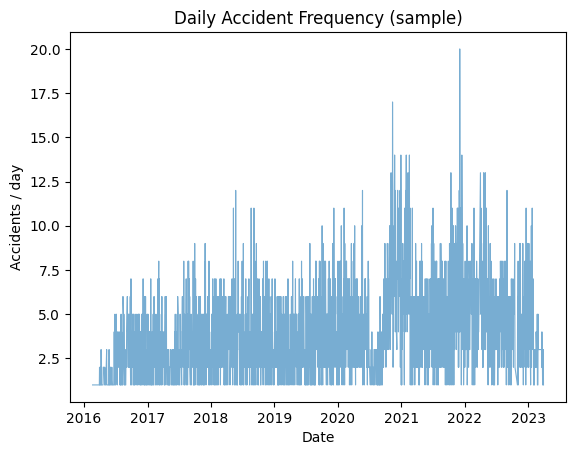

In [4]:
# plot daily accident counts over the full date range
plt.plot(daily_counts['Date'], daily_counts['Accident_Count'], alpha=0.6, lw=0.8)
plt.xlabel('Date')
plt.ylabel('Accidents / day')
plt.title('Daily Accident Frequency (sample)')
plt.show();

In [5]:
dates  = pd.to_datetime(daily_counts['Date'])
t_days = (dates - dates.iloc[0]).dt.days.values.astype(float)
t_norm = t_days / t_days.max()   # normalise to [0,1] for numerical stability

n   = len(daily_counts)
dow = dates.dt.dayofweek.values

# annual Fourier features (3 harmonics) - captures within-year seasonal cycles
annual_feats = []
for k in range(1, 4):
    annual_feats.append(np.sin(2 * np.pi * k * t_days / 365.25))
    annual_feats.append(np.cos(2 * np.pi * k * t_days / 365.25))

# weekly Fourier features (3 harmonics) - captures Mon-Sun recurring pattern
weekly_feats = []
for k in range(1, 4):
    weekly_feats.append(np.sin(2 * np.pi * k * dow / 7))
    weekly_feats.append(np.cos(2 * np.pi * k * dow / 7))

# COVID-19 indicator for the US lockdown and initial recovery window
covid_start = pd.Timestamp('2020-03-01')
covid_end   = pd.Timestamp('2020-08-31')
covid_dummy = ((dates >= covid_start) & (dates <= covid_end)).astype(float).values

# design matrix: intercept | linear trend | quadratic trend | 6 annual | 6 weekly | covid
X = np.column_stack([
    np.ones(n),
    t_norm,
    t_norm ** 2,
    *annual_feats,
    *weekly_feats,
    covid_dummy
])
y = daily_counts['Accident_Count'].values.astype(float)

print(f'Design matrix: {X.shape[0]} days x {X.shape[1]} features')

Design matrix: 2236 days x 16 features


In [6]:
# use the first 80% of days for training, the last 20% for testing
split = int(len(daily_counts) * 0.8)
train = daily_counts[:split]
test  = daily_counts[split:]
print(f'Training on {len(train)} days, testing on {len(test)} days')

Training on 1788 days, testing on 448 days


In [7]:
dates  = pd.to_datetime(daily_counts['Date'])
t_days = (dates - dates.iloc[0]).dt.days.values.astype(float)
t_norm = t_days / t_days.max()  # scale to [0,1] for numerical stability

n   = len(daily_counts)
dow = dates.dt.dayofweek.values

# sin/cos pairs encode the yearly cycle; 3 harmonics capture the shape
annual_feats = []
for k in range(1, 4):
    annual_feats.append(np.sin(2 * np.pi * k * t_days / 365.25))
    annual_feats.append(np.cos(2 * np.pi * k * t_days / 365.25))

# weekly cycle using day-of-week
weekly_feats = []
for k in range(1, 4):
    weekly_feats.append(np.sin(2 * np.pi * k * dow / 7))
    weekly_feats.append(np.cos(2 * np.pi * k * dow / 7))

# binary flag for the COVID lockdown window
covid_start = pd.Timestamp('2020-03-01')
covid_end   = pd.Timestamp('2020-08-31')
covid_dummy = ((dates >= covid_start) & (dates <= covid_end)).astype(float).values

# assemble design matrix: intercept, linear trend, quadratic trend, annual, weekly, covid
X = np.column_stack([
    np.ones(n),
    t_norm,
    t_norm ** 2,
    *annual_feats,
    *weekly_feats,
    covid_dummy
])
y = daily_counts['Accident_Count'].values.astype(float)

print(f'Design matrix: {X.shape[0]} days x {X.shape[1]} features')

Design matrix: 2236 days x 16 features


## Model 2: AR(7)

  intercept    +1.0891
  lag_1        +0.1734
  lag_2        +0.0718
  lag_3        +0.0233
  lag_4        +0.0261
  lag_5        +0.0638
  lag_6        +0.1660
  lag_7        +0.1894
Train R² = 0.2035
Test  R² = 0.1036


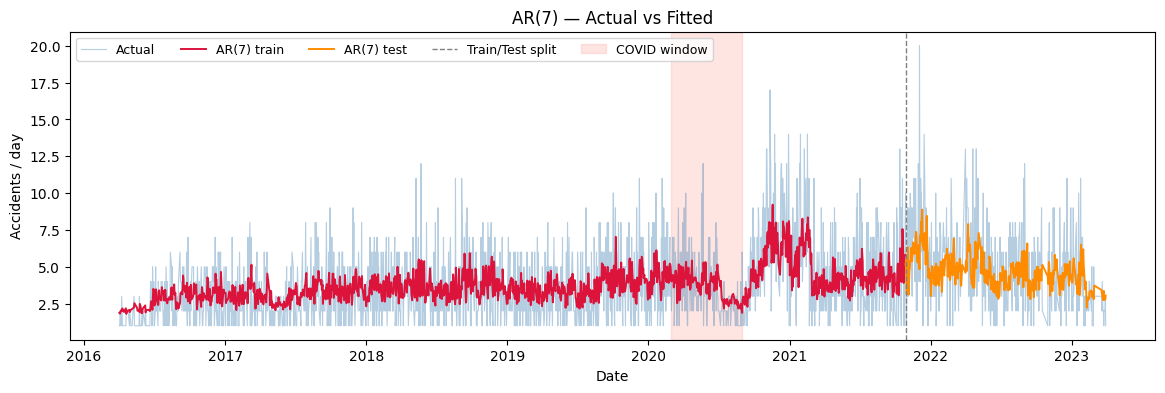

In [11]:
# use the past 7 days (one weekly cycle) as features to predict today
p    = 7
n_ar = len(y) - p

# each column is y shifted back by i+1 days
X_ar = np.column_stack([y[p - i - 1 : n_ar + p - i - 1] for i in range(p)])
X_ar = np.column_stack([np.ones(n_ar), X_ar])
y_ar = y[p:]

split_ar = split - p
X_ar_train, X_ar_test = X_ar[:split_ar], X_ar[split_ar:]
y_ar_train, y_ar_test = y_ar[:split_ar], y_ar[split_ar:]

# solve OLS normal equations
w_ar = np.dot(np.linalg.inv(np.dot(X_ar_train.T, X_ar_train)),
              np.dot(X_ar_train.T, y_ar_train))

# print lag weights
labels = ['intercept'] + [f'lag_{i+1}' for i in range(p)]
for name, b in zip(labels, w_ar):
    print(f'  {name:<12} {b:+.4f}')

y_ar_pred_train = X_ar_train @ w_ar
y_ar_pred_test  = X_ar_test  @ w_ar

print(f'Train R² = {r2(y_ar_train, y_ar_pred_train):.4f}')
print(f'Test  R² = {r2(y_ar_test,  y_ar_pred_test):.4f}')

# plot actual vs fitted
dates_ar      = dates.iloc[p:].reset_index(drop=True)
split_date_ar = dates_ar.iloc[split_ar]

plt.figure(figsize=(14, 4))
plt.plot(dates_ar, y_ar, color='steelblue', alpha=0.4, lw=0.8, label='Actual')
plt.plot(dates_ar[:split_ar], y_ar_pred_train, color='crimson',    lw=1.4, label='AR(7) train')
plt.plot(dates_ar[split_ar:], y_ar_pred_test,  color='darkorange', lw=1.4, label='AR(7) test')
plt.axvline(split_date_ar, color='gray', ls='--', lw=1, label='Train/Test split')
plt.axvspan(covid_start, covid_end, color='salmon', alpha=0.2, label='COVID window')
plt.xlabel('Date')
plt.ylabel('Accidents / day')
plt.title('AR(7) — Actual vs Fitted')
plt.legend(ncol=5, fontsize=9)
plt.show();

## Model 3: SARMA(1,1)(1,1)₇ via Hannan-Rissanen

  intercept    +0.5249
  AR(1)        +0.2726
  MA(1)        -0.1370
  SAR(1)_7     +0.5882
  SMA(1)_7     -0.4420
Train R² = 0.1987
Test  R² = 0.1547


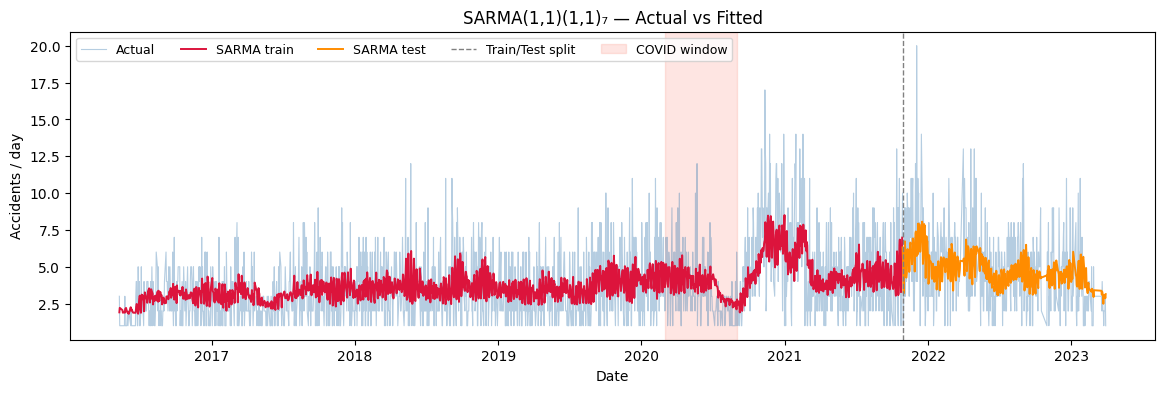

In [16]:
s = 7   # seasonal period (weekly)
m = 20  # long AR order used to approximate innovations

# step 1: fit a long AR(20) to get residual proxies for the MA terms
X_init = np.column_stack([np.ones(len(y) - m)] +
                          [y[m - i - 1 : len(y) - i - 1] for i in range(m)])
w_init      = np.dot(np.linalg.inv(np.dot(X_init.T, X_init)), np.dot(X_init.T, y[m:]))
eps_hat     = np.zeros(len(y))
eps_hat[m:] = y[m:] - X_init @ w_init

# step 2: build SARMA features using observed y values and residual proxies
# start at t0 = m+s so all lags are available
t0      = m + s
n_sarma = len(y) - t0

X_sarma = np.column_stack([
    np.ones(n_sarma),
    y[t0 - 1       : t0 - 1 + n_sarma],    # AR(1):    y_{t-1}
    eps_hat[t0 - 1 : t0 - 1 + n_sarma],    # MA(1):    eps_{t-1}
    y[t0 - s       : t0 - s + n_sarma],    # SAR(1)_7: y_{t-7}
    eps_hat[t0 - s : t0 - s + n_sarma],    # SMA(1)_7: eps_{t-7}
])
y_sarma = y[t0:]

split_sarma = split - t0
X_sarma_train, X_sarma_test = X_sarma[:split_sarma], X_sarma[split_sarma:]
y_sarma_train, y_sarma_test = y_sarma[:split_sarma], y_sarma[split_sarma:]

# solve OLS normal equations
w_sarma = np.dot(np.linalg.inv(np.dot(X_sarma_train.T, X_sarma_train)),
                 np.dot(X_sarma_train.T, y_sarma_train))

sarma_labels = ['intercept', 'AR(1)', 'MA(1)', 'SAR(1)_7', 'SMA(1)_7']
for name, b in zip(sarma_labels, w_sarma):
    print(f'  {name:<12} {b:+.4f}')

y_sarma_pred_train = X_sarma_train @ w_sarma
y_sarma_pred_test  = X_sarma_test  @ w_sarma

print(f'Train R² = {r2(y_sarma_train, y_sarma_pred_train):.4f}')
print(f'Test  R² = {r2(y_sarma_test,  y_sarma_pred_test):.4f}')

# plot actual vs fitted
dates_sarma      = dates.iloc[t0:].reset_index(drop=True)
split_date_sarma = dates_sarma.iloc[split_sarma]

plt.figure(figsize=(14, 4))
plt.plot(dates_sarma, y_sarma, color='steelblue', alpha=0.4, lw=0.8, label='Actual')
plt.plot(dates_sarma[:split_sarma], y_sarma_pred_train, color='crimson',    lw=1.4, label='SARMA train')
plt.plot(dates_sarma[split_sarma:], y_sarma_pred_test,  color='darkorange', lw=1.4, label='SARMA test')
plt.axvline(split_date_sarma, color='gray', ls='--', lw=1, label='Train/Test split')
plt.axvspan(covid_start, covid_end, color='salmon', alpha=0.2, label='COVID window')
plt.xlabel('Date')
plt.ylabel('Accidents / day')
plt.title('SARMA(1,1)(1,1)₇ — Actual vs Fitted')
plt.legend(ncol=5, fontsize=9)
plt.show();

## Model Comparison

In [17]:
s = 7   # seasonal period (weekly)
m = 20  # long AR order used to approximate innovations

# step 1: fit a long AR(20) to get residual proxies for the MA terms
X_init = np.column_stack([np.ones(len(y) - m)] +
                          [y[m - i - 1 : len(y) - i - 1] for i in range(m)])
w_init      = np.dot(np.linalg.inv(np.dot(X_init.T, X_init)), np.dot(X_init.T, y[m:]))
eps_hat     = np.zeros(len(y))
eps_hat[m:] = y[m:] - X_init @ w_init

print(f'Residual std from long AR: {eps_hat[m:].std():.3f}')

Residual std from long AR: 2.223


In [18]:
# step 2: build SARMA features using observed y values and residual proxies
# start at t0 = m+s so all lags are available
t0      = m + s
n_sarma = len(y) - t0

X_sarma = np.column_stack([
    np.ones(n_sarma),
    y[t0 - 1       : t0 - 1 + n_sarma],    # AR(1):    y_{t-1}
    eps_hat[t0 - 1 : t0 - 1 + n_sarma],    # MA(1):    eps_{t-1}
    y[t0 - s       : t0 - s + n_sarma],    # SAR(1)_7: y_{t-7}
    eps_hat[t0 - s : t0 - s + n_sarma],    # SMA(1)_7: eps_{t-7}
])
y_sarma = y[t0:]

split_sarma = split - t0
X_sarma_train, X_sarma_test = X_sarma[:split_sarma], X_sarma[split_sarma:]
y_sarma_train, y_sarma_test = y_sarma[:split_sarma], y_sarma[split_sarma:]

# solve OLS normal equations
w_sarma = np.dot(np.linalg.inv(np.dot(X_sarma_train.T, X_sarma_train)),
                 np.dot(X_sarma_train.T, y_sarma_train))

sarma_labels = ['intercept', 'AR(1)', 'MA(1)', 'SAR(1)_7', 'SMA(1)_7']
for name, b in zip(sarma_labels, w_sarma):
    print(f'  {name:<12} {b:+.4f}')

  intercept    +0.5249
  AR(1)        +0.2726
  MA(1)        -0.1370
  SAR(1)_7     +0.5882
  SMA(1)_7     -0.4420
